# GPT Pretrain Notebook

이 노트북은 `src/train.py`와 `src/bpe.py`를 그대로 사용해서 최종 어휘 사전 생성과 GPT 사전학습 실행만 따로 모아둔 버전입니다.


## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다. 로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.


In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")


Repo: C:\Jungle\Jungle_GPT_lab


## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다. `download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.


In [2]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)


이미 존재합니다: c:\Jungle\Jungle_GPT_lab\data\ratings_train.txt
이미 존재합니다: c:\Jungle\Jungle_GPT_lab\data\ratings_test.txt
사전 학습 train 텍스트: c:\Jungle\Jungle_GPT_lab\data\nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: c:\Jungle\Jungle_GPT_lab\data\nsmc_lm_val.txt (120,560자)
감성 분류 train: c:\Jungle\Jungle_GPT_lab\data\nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: c:\Jungle\Jungle_GPT_lab\data\nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: c:\Jungle\Jungle_GPT_lab\data\nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True C:\Jungle\Jungle_GPT_lab\data\nsmc_lm_train.txt
LM val exists: True C:\Jungle\Jungle_GPT_lab\data\nsmc_lm_val.txt


In [3]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. 6.5 어휘 사전 훈련

사용 파일: `data/nsmc_lm_train.txt`, `data/nsmc_lm_val.txt`

권장 순서:
1. `corpus[:5000]`, `vocab_size=300`으로 인코딩/디코딩 복원 확인
2. `corpus[:100000]`, `vocab_size=1000`으로 시간 확인
3. Light 또는 Basic 설정으로 확장
4. `tokenizer.save(path)`로 저장
5. 다음 실행부터는 `tokenizer.load(path)` 사용

이 노트북은 확인용 셀은 생략하고, 최종 어휘 사전만 `data/nsmc_bpe_vocab_3000.json`에 저장하는 흐름으로 구성했습니다.


In [11]:
import torch
from pathlib import Path

# Change only this cell when you want to re-run with different settings.
PRETRAIN_CFG = {
    "run_name": "quick_pretrain",
    "seed": 42,
    "tokenizer_vocab_size": 3000,
    "tokenizer_train_chars": 1_500_000,
    "force_rebuild_tokenizer": False,
    "force_reencode": False,
    "train_text_limit": None,
    "val_text_limit": None,
    "context_length": 128,
    "stride": 64,
    "batch_size": 4,
    "emb_dim": 256,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.15,
    "qkv_bias": False,
    "learning_rate": 2e-4,
    "weight_decay": 0.03,
    "num_epochs": 12,
    "eval_freq": 200,
    "eval_iter": 10,
    "ckpt_freq": 1,
    "num_workers": 0,
    "start_context": "영화",
    "resume_checkpoint": None,
}

PRETRAIN_CFG["device"] = "cuda" if torch.cuda.is_available() else "cpu"
PRETRAIN_CFG["tokenizer_path"] = repo_dir / "data" / f"nsmc_bpe_vocab_{PRETRAIN_CFG['tokenizer_vocab_size']}.json"
PRETRAIN_CFG["final_checkpoint_path"] = repo_dir / "checkpoints" / f"{PRETRAIN_CFG['run_name']}_final.pt"
PRETRAIN_CFG["encoded_cache_dir"] = repo_dir / "checkpoints" / "encoded_cache"

{k: str(v) if isinstance(v, Path) else v for k, v in PRETRAIN_CFG.items()}


{'run_name': 'quick_pretrain',
 'seed': 42,
 'tokenizer_vocab_size': 3000,
 'tokenizer_train_chars': 1500000,
 'force_rebuild_tokenizer': False,
 'force_reencode': False,
 'train_text_limit': None,
 'val_text_limit': None,
 'context_length': 128,
 'stride': 64,
 'batch_size': 4,
 'emb_dim': 256,
 'n_heads': 4,
 'n_layers': 4,
 'drop_rate': 0.15,
 'qkv_bias': False,
 'learning_rate': 0.0002,
 'weight_decay': 0.03,
 'num_epochs': 12,
 'eval_freq': 200,
 'eval_iter': 10,
 'ckpt_freq': 1,
 'num_workers': 0,
 'start_context': '영화',
 'resume_checkpoint': None,
 'device': 'cuda',
 'tokenizer_path': 'C:\\Jungle\\Jungle_GPT_lab\\data\\nsmc_bpe_vocab_3000.json',
 'final_checkpoint_path': 'C:\\Jungle\\Jungle_GPT_lab\\checkpoints\\quick_pretrain_final.pt',
 'encoded_cache_dir': 'C:\\Jungle\\Jungle_GPT_lab\\checkpoints\\encoded_cache'}

## 4. 최종 어휘 사전 저장

`data/nsmc_bpe_vocab_3000.json`이 이미 있으면 로드하고, 없으면 `corpus[:1_500_000]`으로 학습한 뒤 저장합니다.


In [5]:
import hashlib
import importlib
import json
from pathlib import Path

import bpe

importlib.reload(bpe)

cfg = PRETRAIN_CFG.copy()
vocab_path = Path(cfg["tokenizer_path"])
tokenizer_source_text = corpus if cfg["tokenizer_train_chars"] in (None, 0) else corpus[: cfg["tokenizer_train_chars"]]

print(f"[tokenizer] target path: {vocab_path}")
print(f"[tokenizer] source chars: {len(tokenizer_source_text):,}")
print(f"[tokenizer] vocab size:   {cfg['tokenizer_vocab_size']}")

if cfg["force_rebuild_tokenizer"] and vocab_path.exists():
    vocab_path.unlink()
    print(f"[tokenizer] removed old file: {vocab_path}")

tokenizer = bpe.BPETokenizer(vocab_size=cfg["tokenizer_vocab_size"])
if vocab_path.exists():
    print(f"[tokenizer] loading from {vocab_path}")
    tokenizer.load(vocab_path)
else:
    print(f"[tokenizer] training start (vocab_size={cfg['tokenizer_vocab_size']})")
    tokenizer.train(tokenizer_source_text)
    vocab_path.parent.mkdir(parents=True, exist_ok=True)
    tokenizer.save(vocab_path)
    print(f"[tokenizer] saved to {vocab_path}")

TOKENIZER_ARTIFACTS = {
    "tokenizer": tokenizer,
    "path": vocab_path,
    "source_chars": len(tokenizer_source_text),
    "vocab_size": cfg["tokenizer_vocab_size"],
}

TOKENIZER_ARTIFACTS


[tokenizer] target path: C:\Jungle\Jungle_GPT_lab\data\nsmc_bpe_vocab_3000.json
[tokenizer] source chars: 1,379,486
[tokenizer] vocab size:   3000
[tokenizer] loading from C:\Jungle\Jungle_GPT_lab\data\nsmc_bpe_vocab_3000.json


{'tokenizer': <bpe.BPETokenizer at 0x1f4a87ce310>,
 'path': WindowsPath('C:/Jungle/Jungle_GPT_lab/data/nsmc_bpe_vocab_3000.json'),
 'source_chars': 1379486,
 'vocab_size': 3000}

## 5. GPT 사전학습 실행

이 셀은 `src/train.py`의 `train_model`, `load_checkpoint`, `save_checkpoint`, `evaluate_model`을 그대로 사용합니다.


### 5-1. 인코딩 준비

토크나이저를 불러오고, `train_ids` / `val_ids` 캐시를 준비합니다. 같은 설정이면 캐시를 다시 사용합니다.


In [6]:
import hashlib
import importlib
import json
from pathlib import Path

import torch

import bpe

importlib.reload(bpe)

cfg = PRETRAIN_CFG.copy()
device = torch.device(cfg["device"])
torch.manual_seed(cfg["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg["seed"])

train_text = corpus if cfg["train_text_limit"] in (None, 0) else corpus[: cfg["train_text_limit"]]
val_text = val_corpus if cfg["val_text_limit"] in (None, 0) else val_corpus[: cfg["val_text_limit"]]
tokenizer_path = Path(cfg["tokenizer_path"])

print(f"[device] {device}")
print(f"[text] train chars: {len(train_text):,}")
print(f"[text] val chars:   {len(val_text):,}")

if not train_text or not val_text:
    raise RuntimeError("LM train/val text is empty. Check the data preparation cells first.")

if "TOKENIZER_ARTIFACTS" in globals() and Path(TOKENIZER_ARTIFACTS["path"]) == tokenizer_path:
    tokenizer = TOKENIZER_ARTIFACTS["tokenizer"]
    print(f"[tokenizer] using tokenizer from TOKENIZER_ARTIFACTS: {tokenizer_path}")
else:
    tokenizer = bpe.BPETokenizer(vocab_size=cfg["tokenizer_vocab_size"])
    if tokenizer_path.exists():
        print(f"[tokenizer] loading from {tokenizer_path}")
        tokenizer.load(tokenizer_path)
    else:
        tokenizer_source_text = corpus if cfg["tokenizer_train_chars"] in (None, 0) else corpus[: cfg["tokenizer_train_chars"]]
        print(f"[tokenizer] training start (vocab_size={cfg['tokenizer_vocab_size']})")
        tokenizer.train(tokenizer_source_text)
        tokenizer_path.parent.mkdir(parents=True, exist_ok=True)
        tokenizer.save(tokenizer_path)
        print(f"[tokenizer] saved to {tokenizer_path}")

def encode_corpus_lines(name: str, text: str, tokenizer):
    token_ids = []
    lines = text.splitlines()
    total_lines = len(lines)
    print(f"[encode:{name}] start ({total_lines:,} lines)")

    for idx, line in enumerate(lines, start=1):
        line = line.strip()
        if not line:
            continue
        token_ids.extend(tokenizer.encode(line, add_bos_eos=True))

        if idx % 5000 == 0 or idx == total_lines:
            print(f"[encode:{name}] {idx:,}/{total_lines:,} lines ({len(token_ids):,} tokens)")

    print(f"[encode:{name}] done ({len(token_ids):,} tokens)")
    return token_ids

encoded_cache_dir = Path(cfg["encoded_cache_dir"])
encoded_cache_dir.mkdir(parents=True, exist_ok=True)
cache_payload = {
    "tokenizer_path": str(tokenizer_path.resolve()),
    "tokenizer_mtime_ns": tokenizer_path.stat().st_mtime_ns if tokenizer_path.exists() else None,
    "tokenizer_vocab_size": cfg["tokenizer_vocab_size"],
    "train_text_limit": cfg["train_text_limit"],
    "val_text_limit": cfg["val_text_limit"],
    "train_chars": len(train_text),
    "val_chars": len(val_text),
    "lm_train_path": str(LM_TRAIN_PATH.resolve()),
    "lm_train_mtime_ns": LM_TRAIN_PATH.stat().st_mtime_ns if LM_TRAIN_PATH.exists() else None,
    "lm_val_path": str(LM_VAL_PATH.resolve()),
    "lm_val_mtime_ns": LM_VAL_PATH.stat().st_mtime_ns if LM_VAL_PATH.exists() else None,
}
cache_key = hashlib.sha256(json.dumps(cache_payload, sort_keys=True, ensure_ascii=False).encode("utf-8")).hexdigest()[:12]
train_ids_path = encoded_cache_dir / f"train_ids_{cache_key}.pt"
val_ids_path = encoded_cache_dir / f"val_ids_{cache_key}.pt"
print(f"[encode-cache] key: {cache_key}")
print(f"[encode-cache] train path: {train_ids_path}")
print(f"[encode-cache] val path:   {val_ids_path}")

use_cached_ids = (
    not cfg.get("force_reencode", False)
    and train_ids_path.exists()
    and val_ids_path.exists()
)

if use_cached_ids:
    print("[encode-cache] loading cached token ids")
    cached_train = torch.load(train_ids_path, map_location="cpu")
    cached_val = torch.load(val_ids_path, map_location="cpu")
    train_ids = cached_train["token_ids"] if isinstance(cached_train, dict) else cached_train
    val_ids = cached_val["token_ids"] if isinstance(cached_val, dict) else cached_val
    print(f"[encode:train] loaded ({len(train_ids):,} tokens)")
    print(f"[encode:val] loaded ({len(val_ids):,} tokens)")
else:
    if cfg.get("force_reencode", False):
        print("[encode-cache] force_reencode=True, rebuilding token ids")
    else:
        print("[encode-cache] cache miss, encoding token ids")
    train_ids = encode_corpus_lines("train", train_text, tokenizer)
    val_ids = encode_corpus_lines("val", val_text, tokenizer)
    torch.save({"token_ids": train_ids, "cache_payload": cache_payload}, train_ids_path)
    torch.save({"token_ids": val_ids, "cache_payload": cache_payload}, val_ids_path)
    print("[encode-cache] saved cached token ids")

PRETRAIN_ENCODE_ARTIFACTS = {
    "config": cfg,
    "device": device,
    "tokenizer": tokenizer,
    "tokenizer_path": tokenizer_path,
    "train_ids_path": train_ids_path,
    "val_ids_path": val_ids_path,
    "train_token_count": len(train_ids),
    "val_token_count": len(val_ids),
    "encode_cache_key": cache_key,
}

print(f"[encode-cache] ready: train={len(train_ids):,} tokens, val={len(val_ids):,} tokens")
PRETRAIN_ENCODE_ARTIFACTS


[device] cuda
[text] train chars: 1,379,486
[text] val chars:   120,560
[tokenizer] using tokenizer from TOKENIZER_ARTIFACTS: C:\Jungle\Jungle_GPT_lab\data\nsmc_bpe_vocab_3000.json
[encode-cache] key: 6d9c0acb3b57
[encode-cache] train path: C:\Jungle\Jungle_GPT_lab\checkpoints\encoded_cache\train_ids_6d9c0acb3b57.pt
[encode-cache] val path:   C:\Jungle\Jungle_GPT_lab\checkpoints\encoded_cache\val_ids_6d9c0acb3b57.pt
[encode-cache] cache miss, encoding token ids
[encode:train] start (37,826 lines)
[encode:train] 5,000/37,826 lines (115,668 tokens)
[encode:train] 10,000/37,826 lines (229,012 tokens)
[encode:train] 15,000/37,826 lines (346,307 tokens)
[encode:train] 20,000/37,826 lines (463,321 tokens)
[encode:train] 25,000/37,826 lines (578,115 tokens)
[encode:train] 30,000/37,826 lines (692,424 tokens)
[encode:train] 35,000/37,826 lines (807,319 tokens)
[encode:train] 37,826/37,826 lines (869,883 tokens)
[encode:train] done (869,883 tokens)
[encode:val] start (3,290 lines)
[encode:val] 

{'config': {'run_name': 'quick_pretrain',
  'seed': 42,
  'tokenizer_vocab_size': 3000,
  'tokenizer_train_chars': 1500000,
  'force_rebuild_tokenizer': False,
  'force_reencode': False,
  'train_text_limit': None,
  'val_text_limit': None,
  'context_length': 128,
  'stride': 64,
  'batch_size': 4,
  'emb_dim': 128,
  'n_heads': 4,
  'n_layers': 4,
  'drop_rate': 0.2,
  'qkv_bias': False,
  'learning_rate': 0.0001,
  'weight_decay': 0.05,
  'num_epochs': 10,
  'eval_freq': 300,
  'eval_iter': 10,
  'ckpt_freq': 1,
  'num_workers': 0,
  'start_context': '영화 ',
  'resume_checkpoint': None,
  'device': 'cuda',
  'tokenizer_path': WindowsPath('C:/Jungle/Jungle_GPT_lab/data/nsmc_bpe_vocab_3000.json'),
  'final_checkpoint_path': WindowsPath('C:/Jungle/Jungle_GPT_lab/checkpoints/quick_pretrain_final.pt'),
  'encoded_cache_dir': WindowsPath('C:/Jungle/Jungle_GPT_lab/checkpoints/encoded_cache')},
 'device': device(type='cuda'),
 'tokenizer': <bpe.BPETokenizer at 0x1f4a87ce310>,
 'tokenizer_pat

### 5-2. GPT 사전학습 실행

인코딩 준비 셀에서 만든 캐시를 불러와 dataloader를 만들고 학습을 실행합니다. 모델 파라미터만 바꿀 때는 이 셀만 다시 돌리면 됩니다.


In [12]:
import importlib
from pathlib import Path

import torch

import dataset
import model
import train

importlib.reload(dataset)
importlib.reload(model)
importlib.reload(train)

if "PRETRAIN_ENCODE_ARTIFACTS" not in globals():
    raise RuntimeError("Run the encoding cell above first.")

cfg = PRETRAIN_CFG.copy()
encode_artifacts = PRETRAIN_ENCODE_ARTIFACTS
device = torch.device(cfg["device"])
torch.manual_seed(cfg["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg["seed"])

tokenizer = encode_artifacts["tokenizer"]
train_ids_path = Path(encode_artifacts["train_ids_path"])
val_ids_path = Path(encode_artifacts["val_ids_path"])
cache_key = encode_artifacts["encode_cache_key"]

print(f"[train] loading token ids from cache key: {cache_key}")
cached_train = torch.load(train_ids_path, map_location="cpu")
cached_val = torch.load(val_ids_path, map_location="cpu")
train_ids = cached_train["token_ids"] if isinstance(cached_train, dict) else cached_train
val_ids = cached_val["token_ids"] if isinstance(cached_val, dict) else cached_val
print(f"[train] train tokens: {len(train_ids):,}")
print(f"[train] val tokens:   {len(val_ids):,}")

train_loader = dataset.create_dataloader(
    token_ids=train_ids,
    context_length=cfg["context_length"],
    batch_size=cfg["batch_size"],
    stride=cfg["stride"],
    drop_last=True,
    shuffle=True,
    num_workers=cfg["num_workers"],
)
val_loader = dataset.create_dataloader(
    token_ids=val_ids,
    context_length=cfg["context_length"],
    batch_size=cfg["batch_size"],
    stride=cfg["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=cfg["num_workers"],
)

print(f"[loader] train batches: {len(train_loader):,}")
print(f"[loader] val batches:   {len(val_loader):,}")

model_config = {
    "vocab_size": max(tokenizer.id_to_token.keys()) + 1,
    "context_length": cfg["context_length"],
    "emb_dim": cfg["emb_dim"],
    "n_heads": cfg["n_heads"],
    "n_layers": cfg["n_layers"],
    "drop_rate": cfg["drop_rate"],
    "qkv_bias": cfg["qkv_bias"],
}
print(f"[model] config: {model_config}")

gpt = model.GPTModel(model_config).to(device)
optimizer = torch.optim.AdamW(
    gpt.parameters(),
    lr=cfg["learning_rate"],
    weight_decay=cfg["weight_decay"],
)

start_epoch = 0
global_step = 0
resume_path = cfg["resume_checkpoint"]
if resume_path:
    resume_path = Path(resume_path)
    print(f"[resume] loading from {resume_path}")
    start_epoch, global_step = train.load_checkpoint(gpt, optimizer, str(resume_path), device)
    print(f"[resume] epoch={start_epoch}, global_step={global_step}")

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    was_training = model.training
    model.eval()

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (input_batch, target_batch) in enumerate(data_loader):
            if batch_idx >= num_batches:
                break

            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            logits = model(input_batch)
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == target_batch).sum().item()
            total += target_batch.numel()

    if was_training:
        model.train()

    return correct / total if total > 0 else float("nan")

def evaluate_metrics(model, train_loader, val_loader, device, eval_iter):
    train_loss = train.calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = train.calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
    val_acc = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
    return train_loss, val_loss, train_acc, val_acc

def generate_sample_text(model, tokenizer, device, start_context, context_size, max_new_tokens=50, temperature=0.8, top_k=40):
    was_training = model.training
    model.eval()
    encoded = train.text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = train.generate(
            model,
            encoded,
            max_new_tokens=max_new_tokens,
            context_size=context_size,
            temperature=temperature,
            top_k=top_k,
        )

    decoded_text = train.token_ids_to_text(token_ids, tokenizer).replace("\n", " ")
    decoded_text = decoded_text.replace("|", "\\|").strip()

    if was_training:
        model.train()

    return decoded_text

metric_steps = []
train_losses = []
val_losses = []
train_accs = []
val_accs = []
epoch_samples = []
epoch_metrics = []
tokens_seen = 0

print("[train] entering custom training loop")
for epoch in range(start_epoch, cfg["num_epochs"]):
    gpt.train()

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = train.calc_loss_batch(input_batch, target_batch, gpt, device)
        loss.backward()
        optimizer.step()

        tokens_seen += input_batch.numel()
        global_step += 1

        if cfg["eval_freq"] and global_step % cfg["eval_freq"] == 0:
            train_loss, val_loss, train_acc, val_acc = evaluate_metrics(
                gpt,
                train_loader,
                val_loader,
                device,
                cfg["eval_iter"],
            )
            metric_steps.append(global_step)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            print(
                f"Ep {epoch + 1} (Step {global_step:06d}): "
                f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}, "
                f"Train acc {train_acc:.3%}, Val acc {val_acc:.3%}"
            )

    if cfg["ckpt_freq"] and (epoch + 1) % cfg["ckpt_freq"] == 0:
        ckpt_path = repo_dir / "checkpoints" / f"ckpt_epoch_{epoch + 1}.pt"
        ckpt_path.parent.mkdir(parents=True, exist_ok=True)
        train.save_checkpoint(gpt, optimizer, epoch + 1, global_step, str(ckpt_path))

    epoch_train_loss, epoch_val_loss, epoch_train_acc, epoch_val_acc = evaluate_metrics(
        gpt,
        train_loader,
        val_loader,
        device,
        cfg["eval_iter"],
    )
    epoch_val_ppl = float(torch.exp(torch.tensor(epoch_val_loss)).item())
    epoch_metrics.append(
        {
            "epoch": epoch + 1,
            "step": global_step,
            "train_loss": epoch_train_loss,
            "val_loss": epoch_val_loss,
            "train_acc": epoch_train_acc,
            "val_acc": epoch_val_acc,
            "val_ppl": epoch_val_ppl,
        }
    )
    sample_text = generate_sample_text(
        gpt,
        tokenizer,
        device,
        cfg["start_context"],
        context_size=cfg["context_length"],
    )
    epoch_samples.append({"epoch": epoch + 1, "text": sample_text})

print("[train] finished")

final_train_loss, final_val_loss, final_train_acc, final_val_acc = evaluate_metrics(
    gpt,
    train_loader,
    val_loader,
    device,
    cfg["eval_iter"],
)
if epoch_metrics:
    best_epoch_metric = min(epoch_metrics, key=lambda x: x["val_loss"])
    best_val_loss = best_epoch_metric["val_loss"]
    best_epoch = best_epoch_metric["epoch"]
else:
    best_val_loss = final_val_loss
    best_epoch = cfg["num_epochs"]

final_checkpoint_path = Path(cfg["final_checkpoint_path"])
final_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
final_global_step = global_step + len(train_loader) * max(0, cfg["num_epochs"] - start_epoch)
train.save_checkpoint(gpt, optimizer, cfg["num_epochs"], final_global_step, str(final_checkpoint_path))
print(f"[checkpoint] final model saved to {final_checkpoint_path}")

PRETRAIN_ARTIFACTS = {
    "config": cfg,
    "model_config": model_config,
    "tokenizer": tokenizer,
    "model": gpt,
    "train_loader": train_loader,
    "val_loader": val_loader,
    "metric_steps": metric_steps,
    "tokens_seen": tokens_seen,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs,
    "epoch_samples": epoch_samples,
    "epoch_metrics": epoch_metrics,
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "final_train_acc": final_train_acc,
    "final_val_acc": final_val_acc,
    "best_val_loss": best_val_loss,
    "best_epoch": best_epoch,
    "train_ids_path": train_ids_path,
    "val_ids_path": val_ids_path,
    "encode_cache_key": cache_key,
    "checkpoint_path": final_checkpoint_path,
}

print("| \ud56d\ubaa9 | \ub0b4\uc6a9 |")
print("| --- | --- |")
print(f"| final train loss | {final_train_loss:.4f} |")
print(f"| final validation loss | {final_val_loss:.4f} |")
print(f"| best validation loss | {best_val_loss:.4f} |")
print(f"| best epoch | {best_epoch} |")

print(f"[summary] eval points: {len(train_losses)}")
print(f"[summary] final train acc:  {final_train_acc:.3%}")
print(f"[summary] final val acc:    {final_val_acc:.3%}")


[train] loading token ids from cache key: 6d9c0acb3b57
[train] train tokens: 869,883
[train] val tokens:   76,010
[loader] train batches: 3,397
[loader] val batches:   149
[model] config: {'vocab_size': 3000, 'context_length': 128, 'emb_dim': 256, 'n_heads': 4, 'n_layers': 4, 'drop_rate': 0.15, 'qkv_bias': False}
[train] entering custom training loop
Ep 1 (Step 000200): Train loss 6.817, Val loss 6.780, Train acc 9.141%, Val acc 8.867%
Ep 1 (Step 000400): Train loss 6.720, Val loss 6.722, Train acc 9.004%, Val acc 8.906%
Ep 1 (Step 000600): Train loss 6.641, Val loss 6.643, Train acc 9.375%, Val acc 8.984%
Ep 1 (Step 000800): Train loss 6.518, Val loss 6.535, Train acc 9.688%, Val acc 9.141%
Ep 1 (Step 001000): Train loss 6.400, Val loss 6.417, Train acc 9.805%, Val acc 9.805%
Ep 1 (Step 001200): Train loss 6.209, Val loss 6.280, Train acc 9.961%, Val acc 10.117%
Ep 1 (Step 001400): Train loss 6.093, Val loss 6.133, Train acc 11.699%, Val acc 10.625%
Ep 1 (Step 001600): Train loss 5.94

## 6. Epoch Metrics Table

epoch ?⑥쐞 metric???쒕줈 ?뺤씤?⑸땲??


In [13]:
if "PRETRAIN_ARTIFACTS" not in globals():
    raise RuntimeError("Run the training cell above first.")

epoch_metrics = PRETRAIN_ARTIFACTS.get("epoch_metrics", [])

if not epoch_metrics:
    print("No saved epoch metrics yet. Re-run the training cell to collect them.")
else:
    print("| epoch | step | train_loss | val_loss | train_acc | val_acc | val_ppl |")
    print("| --- | --- | --- | --- | --- | --- | --- |")
    for metric in epoch_metrics:
        print(
            f"| {metric['epoch']} | {metric['step']} | {metric['train_loss']:.4f} | "
            f"{metric['val_loss']:.4f} | {metric['train_acc']:.4f} | "
            f"{metric['val_acc']:.4f} | {metric['val_ppl']:.4f} |"
        )


| epoch | step | train_loss | val_loss | train_acc | val_acc | val_ppl |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 3397 | 5.3698 | 5.4611 | 0.1418 | 0.1437 | 235.3662 |
| 2 | 6794 | 4.9918 | 5.1930 | 0.1654 | 0.1502 | 180.0040 |
| 3 | 10191 | 4.8161 | 5.0869 | 0.1756 | 0.1564 | 161.8873 |
| 4 | 13588 | 4.7190 | 5.0468 | 0.1811 | 0.1609 | 155.5288 |
| 5 | 16985 | 4.6925 | 5.0044 | 0.1879 | 0.1637 | 149.0668 |
| 6 | 20382 | 4.5271 | 4.9892 | 0.1939 | 0.1682 | 146.8182 |
| 7 | 23779 | 4.4313 | 4.9545 | 0.2117 | 0.1711 | 141.8179 |
| 8 | 27176 | 4.4268 | 4.9533 | 0.2412 | 0.1795 | 141.6407 |
| 9 | 30573 | 4.2751 | 4.9423 | 0.2426 | 0.1869 | 140.0911 |
| 10 | 33970 | 4.2626 | 4.9352 | 0.2555 | 0.1900 | 139.1004 |
| 11 | 37367 | 4.0521 | 4.9260 | 0.2516 | 0.1918 | 137.8299 |
| 12 | 40764 | 4.1516 | 4.9522 | 0.2734 | 0.1943 | 141.4927 |


## 6. 시각화

중간 evaluation loss 곡선과 최종 train/val loss를 시각화합니다.


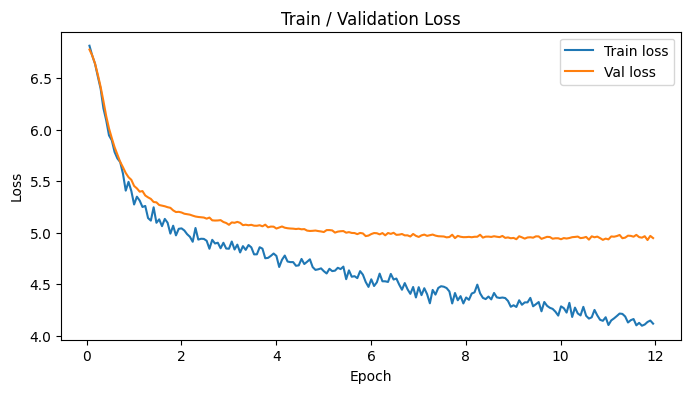

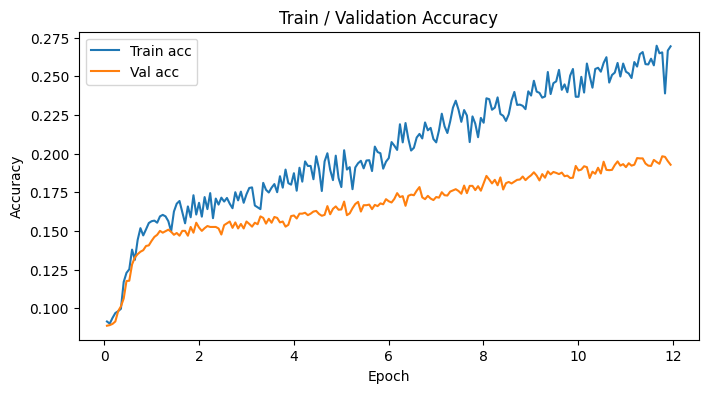

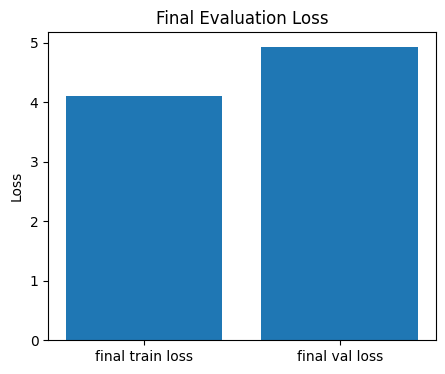

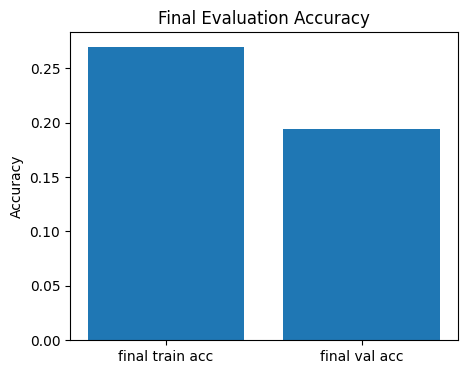

checkpoint: C:\Jungle\Jungle_GPT_lab\checkpoints\quick_pretrain_final.pt


In [14]:
import matplotlib.pyplot as plt

if "PRETRAIN_ARTIFACTS" not in globals():
    raise RuntimeError("Run the training cell above first.")

metric_steps = PRETRAIN_ARTIFACTS["metric_steps"]
train_losses = PRETRAIN_ARTIFACTS["train_losses"]
val_losses = PRETRAIN_ARTIFACTS["val_losses"]
train_accs = PRETRAIN_ARTIFACTS["train_accs"]
val_accs = PRETRAIN_ARTIFACTS["val_accs"]
steps_per_epoch = len(PRETRAIN_ARTIFACTS["train_loader"])
metric_epochs = [step / steps_per_epoch for step in metric_steps] if steps_per_epoch else metric_steps

if train_losses and val_losses:
    plt.figure(figsize=(8, 4))
    plt.plot(metric_epochs, train_losses, label="Train loss")
    plt.plot(metric_epochs, val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train / Validation Loss")
    plt.legend()
    plt.show()
else:
    print("No intermediate loss points yet. Try lowering eval_freq.")

if train_accs and val_accs:
    plt.figure(figsize=(8, 4))
    plt.plot(metric_epochs, train_accs, label="Train acc")
    plt.plot(metric_epochs, val_accs, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Train / Validation Accuracy")
    plt.legend()
    plt.show()
else:
    print("No intermediate accuracy points yet. Try lowering eval_freq.")

plt.figure(figsize=(5, 4))
plt.bar(
    ["final train loss", "final val loss"],
    [PRETRAIN_ARTIFACTS["final_train_loss"], PRETRAIN_ARTIFACTS["final_val_loss"]],
)
plt.ylabel("Loss")
plt.title("Final Evaluation Loss")
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(
    ["final train acc", "final val acc"],
    [PRETRAIN_ARTIFACTS["final_train_acc"], PRETRAIN_ARTIFACTS["final_val_acc"]],
)
plt.ylabel("Accuracy")
plt.title("Final Evaluation Accuracy")
plt.show()

print("checkpoint:", PRETRAIN_ARTIFACTS["checkpoint_path"])


## 7. 에포크별 생성 샘플

학습 셀에서 각 epoch 끝에 생성한 샘플을 한 번에 다시 확인합니다.


In [15]:
if "PRETRAIN_ARTIFACTS" not in globals():
    raise RuntimeError("Run the training cell above first.")

epoch_samples = PRETRAIN_ARTIFACTS.get("epoch_samples", [])

if not epoch_samples:
    print("No saved epoch samples yet. Re-run the training cell to collect them.")
else:
    print("| epoch | \uc0dd\uc131 \uc0d8\ud50c |")
    print("| --- | --- |")
    for sample in epoch_samples:
        sample_text = str(sample["text"]).replace("\n", " ").replace("|", "\\|").strip()
        print(f"| {sample['epoch']} | {sample_text} |")


| epoch | 생성 샘플 |
| --- | --- |
| 1 | 영화어나자의 대표현에 맞았다재밌음재미없어요.영화..최고의 진행한다면정말, 내용을 받았네요.아.이 아니 |
| 2 | 영화보다 낫다는 걸로 다만드는영화...1년의 감동과 그게 아쉽어지는 않나보다.아버지를 하고 개막장이리언가 지금보다.이션을 보이 영화는 |
| 3 | 영화보다 못할정도면 그당시만한 영화였는데 이영화를 보였다 ^^이렇게 무서움도 재미있네재밌음.최고의 영화를 찍어도 9점 준거워주는 배우의 매력적인듯. |
| 4 | 영화...오래서우치가 넘 좋습니다..그리고한국영화는 죄다재밋는데...평점 왜이렇게 재밌게 봤는데 정말 최고다아프고 본사람들이 좋아요재미도 없고 연출 |
| 5 | 영화정말 재밌어요정말로봤는데진짜재밌게 봤어요...재미도 좋고 내용도 지루하고...이렇게 재밋게 봤다 정말 재밌었음내 인생 최고의 영화시지가 않을 영화같음.왜 이런 |
| 6 | 영화네ㅋㅋㅋㅋ아름다운받아서 저질질끌고봤던 기억이.이영화관에서 봤다진짜 재미없다.우연히 봤는데 정말 재미없다 너무나다정말 재밌었어요 ㅜㅜ |
| 7 | 영화수준이자 하는 아쉬움전편하고 뻔한 스토리, 대화의 유명하가.아 이거보단 낫겠음진짜 너무 지루하다...아..ㅋ진짜 재밌음 좋겠네요... |
| 8 | 영화평점 높게 낮은건강희망한다는 것임평점에 낚였다아름다운 작품. 진짜다음식도 괜찮음뭐야?한효과는 좋으나 |
| 9 | 영화지금봐도 재밌는영화였다.이건뭐지....전기세가 아까워요...쓰레기여기서우기세가 아깝다솔직히 이건 그냥 시간날때마다 |
| 10 | 영화보지마자아놔.. 정말 재미없다아 진짜 왜 이렇게 재밌을것같다.잔잔한 것의 한계를 위해서 실망한 사람은 그 순간에 있는 것도 생각한다.이영화를 본 |
| 11 | 영화그냥 좋네재미 있구만지루하고싶으면 더럽게없네..그냥 쓰레기 같아요...평점이 너무 높여...1점도 아까운 쓰레기영화 1점도 아깝다그냥 킬링타임용그저 |
| 12 | 영화보고나는데 이건 뭐라 말아놓고 또 다른거든지.......정말..